# Multiple Linear Regression 

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

## Load dataset

In [2]:
df_encoded = pd.read_csv("../dataset/medical_insurance_encoded.csv")
df_encoded.head()

,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,remainder__age,remainder__bmi,remainder__children,charges
0,0.0,1.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520


In [3]:
df_encoded.shape

(1337, 9)

## Split features x and y

In [4]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

In [5]:
X.head()

,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,remainder__age,remainder__bmi,remainder__children
0,0.0,1.0,0.0,0.0,1.0,19.0,27.900,0.0
1,1.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0
2,1.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0
3,1.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0
4,1.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0


In [6]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

## Train and test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1069, 8)
Test set shape: (268, 8)


## Create and train MLR model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ -101.54,23077.76, -391.76,..., 248.21, 318.7 , 533.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['cat__sex_male','cat__smoker_yes','cat__region_northwest',..., 'remainder__age','remainder__bmi','remainder__children']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.109e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


## Inspect coefficients

In [9]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)
print("Intercept:", model.intercept_)
coefficients

Intercept: -11092.652295946096


,Feature,Coefficient
1,cat__smoker_yes,23077.764593
7,remainder__children,533.009989
6,remainder__bmi,318.701441
5,remainder__age,248.210720
0,cat__sex_male,-101.542054
2,cat__region_northwest,-391.761455
4,cat__region_southwest,-659.139752
3,cat__region_southeast,-838.919616


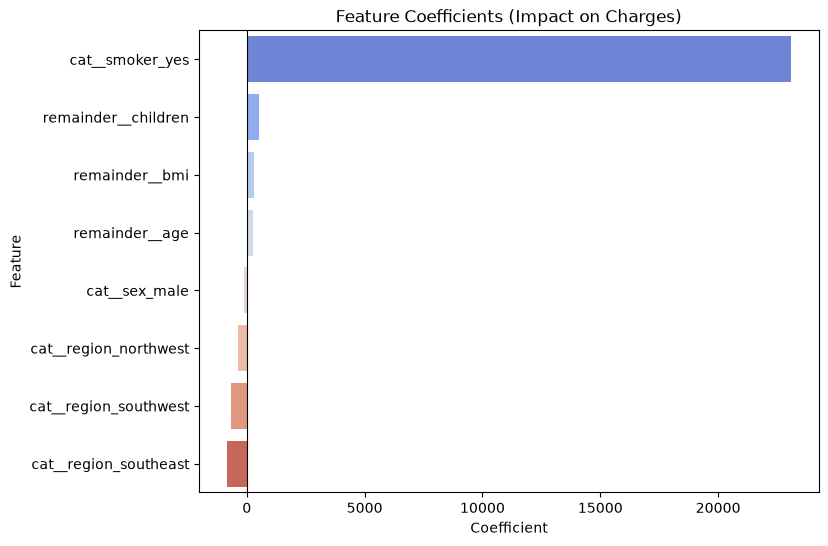

In [10]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    palette="coolwarm",
    legend=False
)

plt.title("Feature Coefficients (Impact on Charges)")
plt.axvline(0, color="black", linewidth=0.8)

plt.show()

## Predict on test set

In [11]:
y_pred = model.predict(X_test)

## Evaluate

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE:  4177.05
MSE:  35478020.68
RMSE: 5956.34
R2 Score: 0.8069


## Visualize Actual vs Predicted Charges

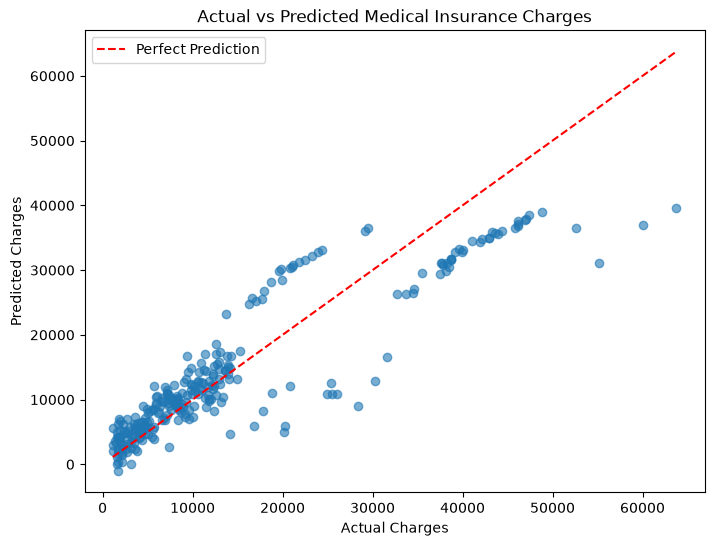

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Insurance Charges")
plt.legend()

plt.show()

## Residual analysis

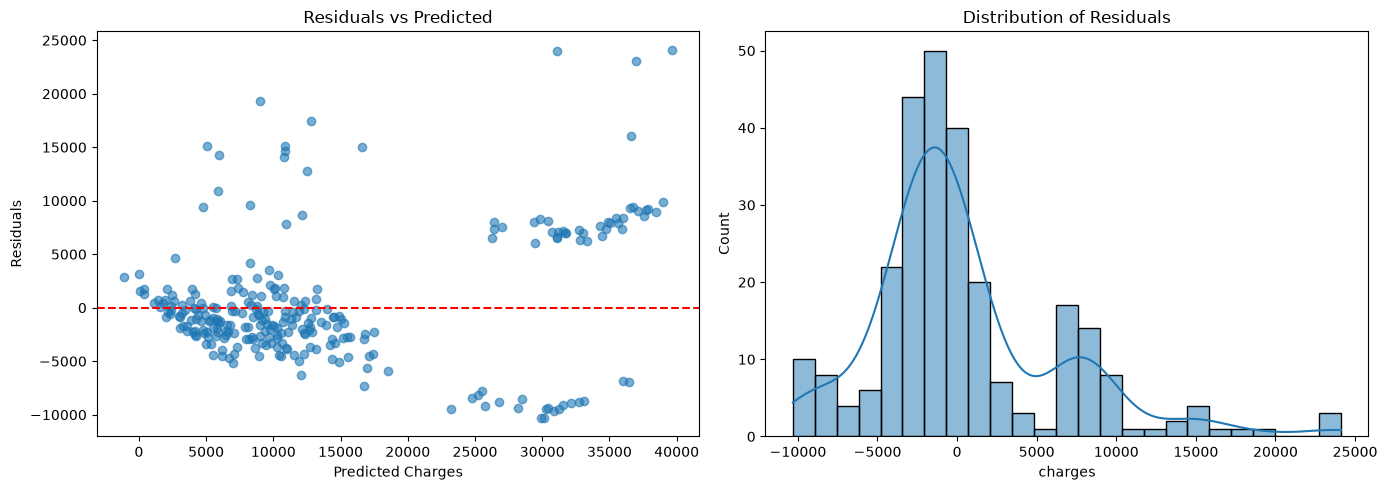

In [14]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Charges")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

## Save the trained model

In [15]:
joblib.dump(model, "../models/multiple_linear_regression_model.pkl")
print("Model saved.")

Model saved.


## Predict on new data

In [ ]:
new_person = {
    "age": 35,
    "sex": "male",         # "male" or "female"
    "bmi": 28.5,
    "children": 2,
    "smoker": "yes",       # "yes" or "no"
    "region": "southeast"  # "northeast", "northwest", "southeast", "southwest"
}

### Encode new person as training data

In [ ]:
def encode_new_person(person, columns):
    row = {
        "cat__sex_male": 1 if person["sex"] == "male" else 0,
        "cat__smoker_yes": 1 if person["smoker"] == "yes" else 0,
        "cat__region_northwest": 1 if person["region"] == "northwest" else 0,
        "cat__region_southeast": 1 if person["region"] == "southeast" else 0,
        "cat__region_southwest": 1 if person["region"] == "southwest" else 0,
        "remainder__age": person["age"],
        "remainder__bmi": person["bmi"],
        "remainder__children": person["children"],
    }

    return pd.DataFrame([row])[columns]

## Save New Person

In [ ]:
new_person_encoded = encode_new_person(new_person, X.columns)
new_person_encoded

### Predict

In [ ]:
predicted_charge = model.predict(new_person_encoded)[0]

print(f"Predicted insurance charge: ${predicted_charge:,.2f}")